In [1]:
from datetime import time
from os import times
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as patches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import math
from cartopy.mpl.ticker import LongitudeFormatter,LatitudeFormatter
from geopy.distance import geodesic
#math的相关函数，import后可以直接使用
from math import radians
from math import sin
from math import cos
from math import asin
from math import sqrt

# np.set_printoptions(threshold=np.inf)#显示所有的数组
from geopy.distance import great_circle
import matplotlib
import seaborn as sns
from scipy import stats

In [2]:
basin_df = pd.read_csv('D:/data/ADT-HURSAT/pnas.1920849117.sd01.csv')
day_df = pd.read_csv('D:/data/ADT-HURSAT/pnas.1920849117.sd02.csv')
hour_df = pd.read_csv('D:/data/ADT-HURSAT/pnas.1920849117.sd03.csv')
lat_df = pd.read_csv('D:/data/ADT-HURSAT/pnas.1920849117.sd04.csv')
lon_df = pd.read_csv('D:/data/ADT-HURSAT/pnas.1920849117.sd05.csv')
month_df = pd.read_csv('D:/data/ADT-HURSAT/pnas.1920849117.sd06.csv')
df7 = pd.read_csv('D:/data/ADT-HURSAT/pnas.1920849117.sd07.csv')
wind_df = pd.read_csv('D:/data/ADT-HURSAT/pnas.1920849117.sd08.csv')
year_df = pd.read_csv('D:/data/ADT-HURSAT/pnas.1920849117.sd09.csv')

In [3]:
# 用于计算弯曲度的函数
def calculate_sinuosity(latitudes, longitudes):
    """
    计算热带气旋路径的弯曲度
    :param latitudes: 纬度序列
    :param longitudes: 经度序列
    :return: 弯曲度
    """
    total_distance = 0  # 总路径长度
    # 计算直线距离
    straight_distance = geodesic((latitudes[0], longitudes[0]), (latitudes[-1], longitudes[-1])).km  
    # 计算路径长度
    for i in range(1, len(latitudes)):
        total_distance += geodesic((latitudes[i-1], longitudes[i-1]), (latitudes[i], longitudes[i])).km
    
    # 计算弯曲度
    sinuosity = total_distance / straight_distance  # 弯曲度
    return sinuosity


In [4]:
#筛选
# 1978-2017的数据，海盆,大于35， active month
mask_basin = basin_df.iloc[:, 0].isin(['WP'])
mask_wind = (wind_df > 35).any(axis=1) 
active_months = [7, 8, 9, 10]

In [5]:
# 存储每年的弯曲度
ressin=[]

# 筛选并计算每年的弯曲度
for i in range(1982, 2018):
    year_sinuosity = []
    # print(i)
    mask_year = (year_df.iloc[:, 0] == i)  # 筛选年份
    mask_selected = (mask_basin & mask_wind & mask_year)  # 应用筛选条件
    relat = lat_df[mask_selected]
    relon = lon_df[mask_selected]
    coords = pd.concat([relat, relon], axis=1)
    for idx, row in coords.iterrows():
        lat_row = row.filter(like="Latitude").dropna().values
        lon_row = row.filter(like="Longitude").dropna().values
        if len(lat_row) >= 9:  # 确保有足够的点来计算弯曲度
            sinuosity = calculate_sinuosity(lat_row, lon_row)
            # print(sinuosity)
            year_sinuosity.append(sinuosity)
    # print(year_sinuosity)
    res=np.mean(year_sinuosity)#一年的
    ressin.append(res)
# print(ressin)

   
    

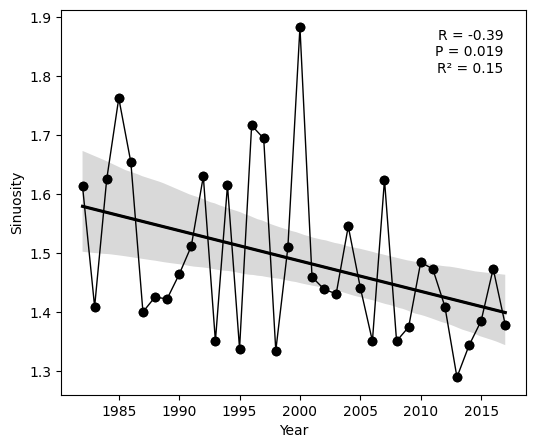

R: -0.3880094129105217
P: 0.019369595668354833
R2: 0.15055130450716772


In [6]:
years = np.arange(1982, 2018)
x=years
y=ressin
#........................................................................................................
fig, ax = plt.subplots(figsize=(6, 5))
# 计算线性回归
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
# 计算 R 方
r_squared = r_value ** 2
ax = sns.regplot(x=x, y=y, ci=95,color='black')
# 绘制散点图和回归线
plt.plot(x,y,'k-o', alpha=1, linewidth=1)
plt.plot(x, intercept + slope * np.array(x), 'black')
# 添加文字（右上角）
textstr = f"R = {r_value:.2f}\nP = {p_value:.3f}\nR² = {r_squared:.2f}"
ax.text(0.95, 0.95, textstr, transform=ax.transAxes,
        fontsize=10, va='top', ha='right')

plt.xlabel('Year')
plt.ylabel('Sinuosity')
plt.show()
print('R:',r_value)
print('P:', p_value)
print('R2:', r_squared)

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def plot_change_data(years, data, ylabel, title, split_index):
    """
    根据输入的年份、数据、分割点、纵坐标标签和图表标题绘制折线图，并标注前后平均值横线。
    
    Parameters:
    years (array-like): 年份序列。
    data (array-like): 对应年份的数值数据。
    ylabel (str): 纵坐标的标签。
    title (str): 图表的标题。
    split_index (int): 数据分割点，用于划分前后部分。
    """
    # 计算分割点之前和之后的平均值
    avg_prior = np.mean(data[:split_index])
    avg_post = np.mean(data[split_index:])
    
    # 绘制数据点及连线
    plt.plot(years, data, '-o', color='red')
    
    # 绘制分割点之前数据的平均值横线
    plt.plot(years[:split_index], [avg_prior] * split_index, color='blue', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
    
    # 绘制分割点之后数据的平均值横线
    plt.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='blue', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
    
    # 添加坐标标签和标题
    plt.xlabel('Year', fontsize=15)
    plt.ylabel(ylabel, fontsize=15)
    plt.title(title,loc='left',fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    
    
    # 添加图例
    plt.legend(loc=1)

    
    P1 = data[:split_index]
    P2 =  data[split_index:]

    # 执行独立样本t检验，默认假设方差不等
    t_stat, p_value = stats.ttest_ind(P1, P2, equal_var=False)
    print(f"T-statistic: {t_stat:.3f}, P-value: {p_value:.3f}")

    plt.title(f't: {t_stat:.2f}, P: {p_value:.2f}',loc='right',fontsize=15)
    
    plt.show()


In [8]:
def sk(data):
    n=len(data)
    Sk     = [0]
    UFk    = [0]
    s      =  0
    E      = [0]
    Var    = [0]
    for i in range(1,n):
        for j in range(i):
            if data[i] > data[j]:
                s = s+1
            else:
                s = s+0
        Sk.append(s)
        E.append((i+1)*(i+2)/4 )                     # Sk[i]的均值
        Var.append((i+1)*i*(2*(i+1)+5)/72 )            # Sk[i]的方差
        UFk.append((Sk[i]-E[i])/np.sqrt(Var[i]))
    UFk=np.array(UFk)
    return UFk

def MK(data, a):
    ufk = sk(data)  # 顺序列
    ubk1 = sk(data[::-1])  # 逆序列
    ubk = -ubk1[::-1]  # 逆转逆序列
    
    # 创建年份范围作为横坐标
    years = np.arange(1982, 2018)  # 生成1982到2023年的数组
    
    # 输出突变点的位置
    p = []
    u = ufk - ubk
    for i in range(1, len(ufk)):
        if u[i-1] * u[i] < 0:
            p.append(i)
    if p:
        print("突变点位置：", p)
    else:
        print("未检测到突变点")
    
    # 画图
    conf_interval = stats.norm.interval(a, loc=0, scale=1)  # 获取置信区间
    plt.rcParams['axes.unicode_minus'] = False  # 解决负号不显示问题
    plt.figure(figsize=(10, 5))
    
    # 使用年份作为横坐标
    plt.plot(years, ufk, label='UFk', color='r')
    plt.plot(years, ubk, label='UBk', color='b')
    
    plt.ylabel('UFk-UBk', fontsize=15)
    x_lim = plt.xlim()
    plt.ylim([-6, 7])
    
    # 绘制置信区间线
    plt.plot(x_lim, [conf_interval[0], conf_interval[0]], '--', color='r', label='95% Confidence Interval')
    plt.plot(x_lim, [conf_interval[1], conf_interval[1]], '--', color='r')
    plt.axhline(0, ls="--", c="k")
    
    # 图例设置
    plt.legend(loc='upper center', frameon=False, ncol=3, fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.xlabel('Year', fontsize=15)
    plt.show()


突变点位置： [1, 2, 5, 9, 11, 12, 13, 14, 16, 17, 19]


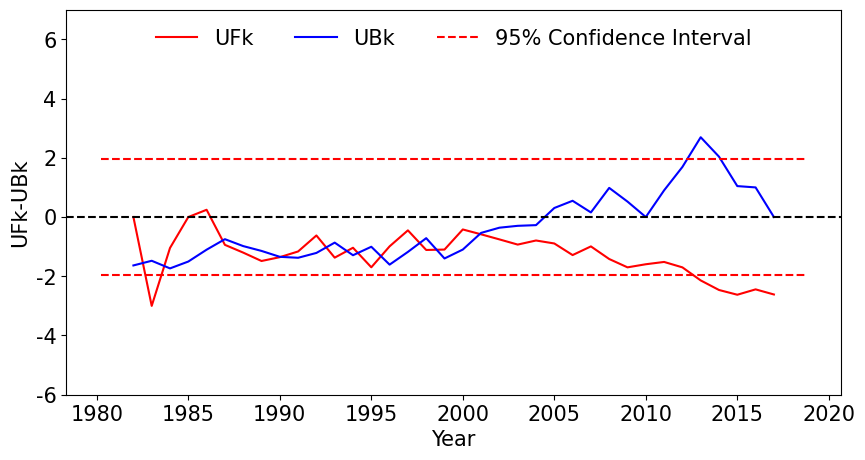

In [9]:
MK(ressin,0.95)

T-statistic: 1.997, P-value: 0.055


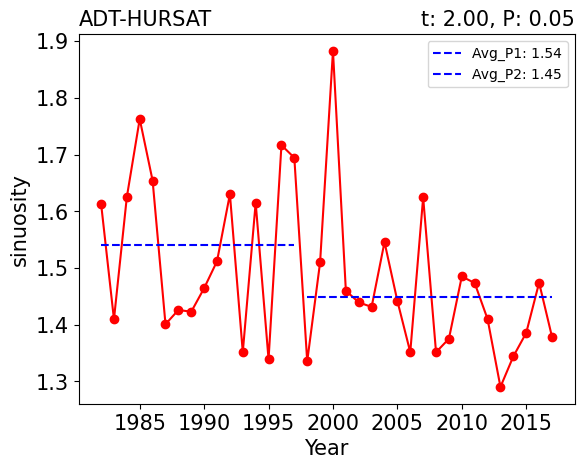

In [12]:
plot_change_data(years, ressin, 'sinuosity', 'ADT-HURSAT', 16)

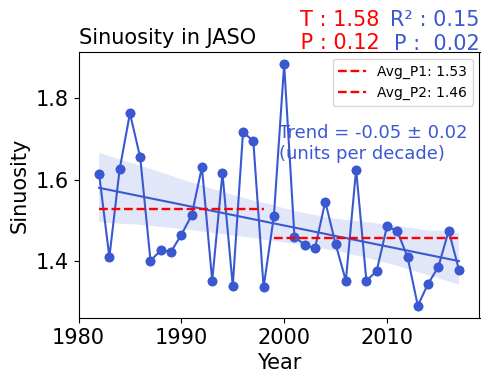

In [29]:
fig, axes = plt.subplots(1,1, figsize=(5, 4))
ax=axes
split_index=17

color1='#3A59D1'
color2=color1
color3='r'



data=ressin
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color=color1,linewidth=1.5)

x=years
y=data
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value ** 2
sns.regplot(x=x, y=y, ci=95,color=color2,ax=ax, line_kws={"linewidth": 1.5})
ax.plot(years[:split_index], [avg_prior] * split_index, color=color3, linestyle='--',linewidth=1.7, label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color=color3, linestyle='--',linewidth=1.7,
        label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Sinuosity', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value2 = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('Sinuosity in JASO',loc='left',fontsize=15)
trend_per_century = slope * 10
std_err_per_century = std_err * 10  # 将标准误差转换为每世纪的不确定性
ax.text(0.5,0.6,f"Trend = {trend_per_century:.2f} ± {std_err_per_century:.2f} \n(units per decade)",
        fontsize=13,c=color1,
       transform=ax.transAxes)

ax.text(0.75, 1.16, f'T : {t_stat:.2f}\n P : {p_value2:.2f}', ha='right', va='top', fontsize=15, color=color3, transform=ax.transAxes)
ax.text(1, 1.16, f'R² : {r_squared:.2f}', 
        ha='right', va='top', fontsize=15, color=color1, transform=ax.transAxes)
ax.text(1, 1.07, f'P :  {p_value:.2f}', 
        ha='right', va='top', fontsize=15, color=color1, transform=ax.transAxes)



# 设置横坐标范围和刻度
ax.set_xlim(1980, 2019)
ax.set_xticks(np.arange(1980, 2020, 10))
ax.set_xticklabels(np.arange(1980, 2020, 10), fontsize=15)

plt.tight_layout()
plt.savefig("02ADT.pdf",transparent = True)


plt.show()